In [2]:
%store -r ising_op

In [23]:
%store -r num_qubits

In [30]:
%store -r df

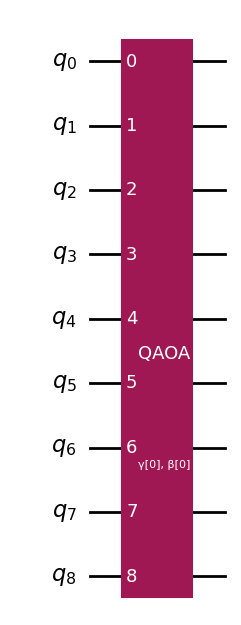

In [3]:
from app.quantum.qaoa import build_qaoa_circuit

qaoa_circuit = build_qaoa_circuit(
    ising_op,
    reps=1
)

qaoa_circuit.draw("mpl")

In [4]:
from app.quantum.simulators import run_statevector

result = run_statevector(qaoa_circuit)

AerError: 'circuits have parameters but parameter_binds is not specified.'

In [5]:
qaoa_circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [6]:
parameter_values = {
    list(qaoa_circuit.parameters)[0]: 0.5,
    list(qaoa_circuit.parameters)[1]: 0.8,
}
bound_circuit = qaoa_circuit.assign_parameters(
    parameter_values
)
bound_circuit.save_statevector()
result = run_statevector(bound_circuit)

In [7]:
statevector = result.get_statevector()

statevector

Statevector([ 0.15997199-9.26746848e-02j,  0.02379492+1.62420005e-02j,
              0.02379492+1.62420005e-02j,  0.03164585-2.75797547e-02j,
              0.02379492+1.62420005e-02j,  0.03164585-2.75797547e-02j,
              0.03164585-2.75797547e-02j,  0.03056516+9.16899645e-03j,
             -0.05462377+4.32083960e-02j, -0.04978525+2.61782437e-03j,
             -0.03179424+1.03398760e-02j, -0.00204909+4.60712240e-02j,
             -0.03179424+1.03398760e-02j, -0.00204909+4.60712240e-02j,
              0.00978623+2.66908165e-02j,  0.02446089-5.95034270e-03j,
             -0.05462377+4.32083960e-02j, -0.03179424+1.03398760e-02j,
             -0.04978525+2.61782437e-03j, -0.00204909+4.60712240e-02j,
             -0.03179424+1.03398760e-02j,  0.00978623+2.66908165e-02j,
             -0.00204909+4.60712240e-02j,  0.02446089-5.95034270e-03j,
              0.02274266-1.88385910e-02j, -0.05236305+6.68709923e-03j,
             -0.05236305+6.68709923e-03j, -0.01493018-6.45202225e-02j,
      

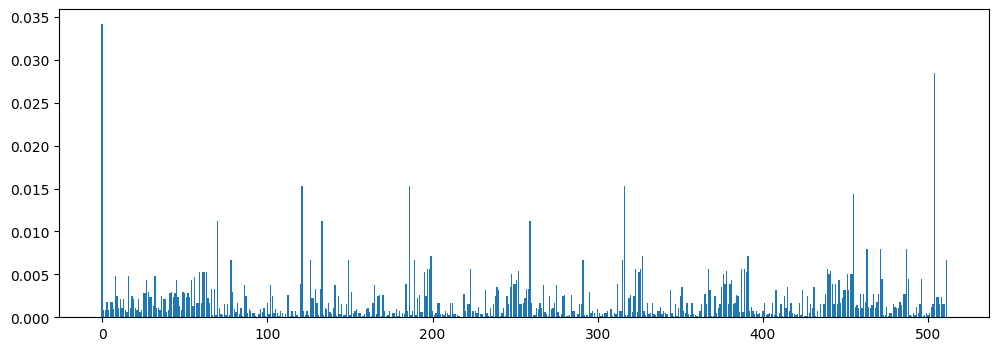

In [9]:
import matplotlib.pyplot as plt

import numpy as np

probs = np.abs(statevector)**2

plt.figure(figsize=(12,4))
plt.bar(range(len(probs)), probs)
plt.show()

In [10]:
from app.quantum.expectation import compute_expectation_value

energy = compute_expectation_value(
    bound_circuit,
    ising_op
)

print(energy)

/usr/local/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.11/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


QiskitError: 'Cannot apply Instruction: save_statevector'

In [11]:
clean_circuit = qaoa_circuit.assign_parameters(
    parameter_values
)

In [12]:
energy = compute_expectation_value(
    clean_circuit,
    ising_op
)

In [13]:
print(energy)

213.05637210442254


In [14]:
import numpy as np

gammas = np.linspace(0, np.pi, 10)
betas = np.linspace(0, np.pi, 10)

landscape = np.zeros(
    (len(gammas), len(betas))
)

In [15]:
len(landscape)

10

In [16]:
params = list(qaoa_circuit.parameters)

for i, gamma in enumerate(gammas):

    for j, beta in enumerate(betas):

        bound = qaoa_circuit.assign_parameters({
            params[0]: beta,
            params[1]: gamma
        })

        energy = compute_expectation_value(
            bound,
            ising_op
        )

        landscape[i, j] = energy
        #print(landscape)

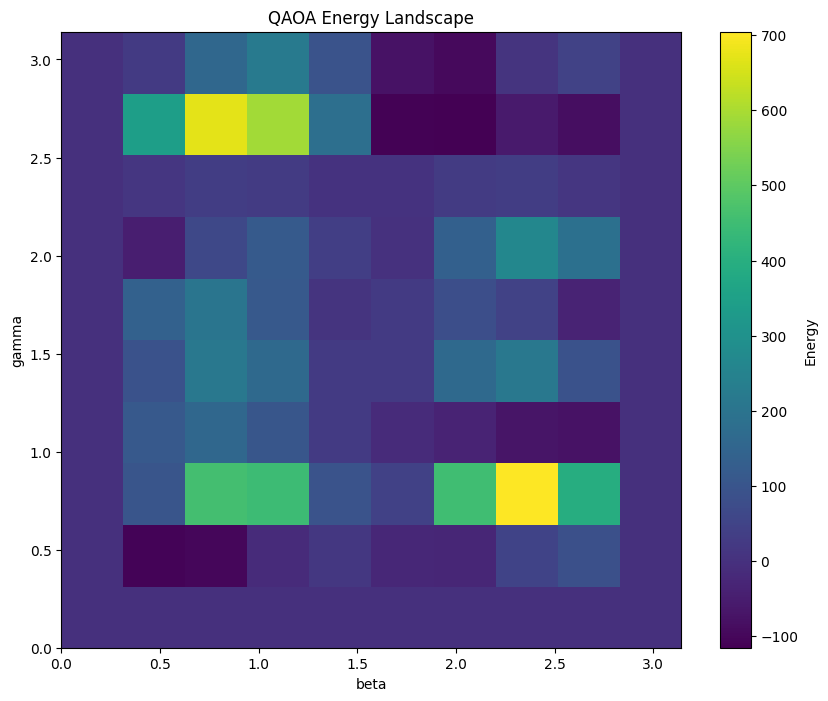

In [17]:
plt.figure(figsize=(10,8))

plt.imshow(
    landscape,
    origin="lower",
    extent=[0, np.pi, 0, np.pi],
    aspect="auto"
)

plt.colorbar(label="Energy")

plt.xlabel(r"beta")
plt.ylabel(r"gamma")

plt.title("QAOA Energy Landscape")

plt.show()

In [19]:
from app.quantum.optimizer import optimize_qaoa

result = optimize_qaoa(
    qaoa_circuit,
    ising_op
)

result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -537.8523216424157
       x: [ 1.894e+00  3.772e-01]
    nfev: 28
   maxcv: 0.0

In [20]:
optimal_params = result.x

params = list(qaoa_circuit.parameters)

optimal_circuit = qaoa_circuit.assign_parameters({
    params[0]: optimal_params[0],
    params[1]: optimal_params[1]
})

In [21]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(
    optimal_circuit
)

probs = np.abs(state.data)**2

In [24]:
top_indices = np.argsort(probs)[-10:]

for idx in reversed(top_indices):

    bitstring = format(
        idx,
        f"0{num_qubits}b"
    )

    print(
        bitstring,
        probs[idx]
    )

000000000 0.027218724094386818
000001000 0.016495581624267855
000010000 0.016495581624267848
000100000 0.016495581624267768
100010001 0.012031805071508228
001100010 0.012031805071508018
100001010 0.012031805071507933
001010100 0.012031805071507912
010100001 0.012031805071507877
010001100 0.012031805071507631


In [25]:
from app.quantum.statevector import (
    get_statevector
)

state = get_statevector(
    optimal_circuit
)

psi = state.data

In [26]:
from app.tensor_networks.mps import (
    statevector_to_mps
)

mps = statevector_to_mps(psi)

mps

MatrixProductState(tensors=9, indices=17, L=9, max_bond=16)

In [27]:
mps.bond_sizes()

[2, 4, 8, 16, 16, 8, 4, 2]

In [28]:
from app.tensor_networks.entanglement import (
    entanglement_entropy
)

sv = mps.schmidt_values(2)

entropy = entanglement_entropy(
    sv
)

print(entropy)

0.6758274927995305


In [37]:
from app.graph.graph_builder import build_graph

from app.graph.distance_matrix import build_distance_matrix

from app.optimization.qubo import build_tsp_qubo

from qiskit_optimization.converters import QuadraticProgramToQubo

qubits = []
bond_dims = []

for n in [2,3,4,5]:

    small_df = df.iloc[:n]

    G = build_graph(small_df)

    D = build_distance_matrix(G)

    qp = build_tsp_qubo(D)

    converter = QuadraticProgramToQubo()

    qubo_problem = converter.convert(qp)

    ising_op, offset = qubo_problem.to_ising()

    qaoa_circuit = build_qaoa_circuit(
        ising_op,
        reps=1
    )

    params = list(
        qaoa_circuit.parameters
    )

    bound = qaoa_circuit.assign_parameters({
        params[0]: 0.5,
        params[1]: 0.8
    })

    state = get_statevector(bound)

    mps = statevector_to_mps(
        state.data
    )

    max_bond = max(
        mps.bond_sizes()
    )

    qubits.append(
        len(state.data)
    )

    bond_dims.append(
        max_bond
    )

MemoryError: Unable to allocate 64.0 GiB for an array with shape (65536, 65536) and data type complex128

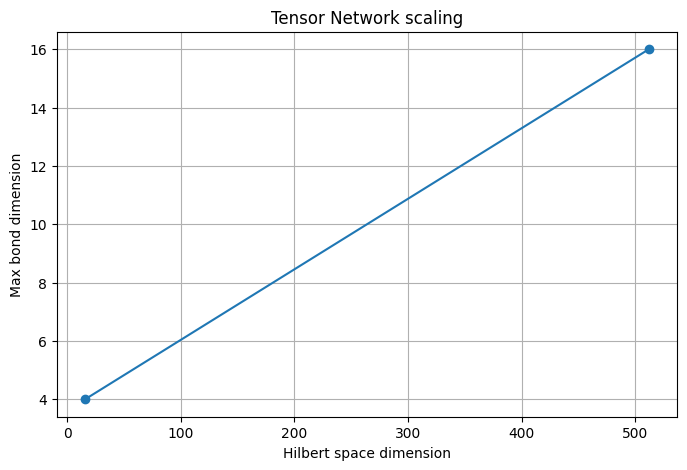

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    qubits,
    bond_dims,
    marker="o"
)

plt.xlabel("Hilbert space dimension")
plt.ylabel("Max bond dimension")

plt.title(
    "Tensor Network scaling"
)

plt.grid(True)

plt.show()

In [39]:
import quimb.tensor as qtn

n_qubits = 20

circ = qtn.Circuit(n_qubits)

In [40]:
for i in range(n_qubits):
    circ.h(i)

In [41]:
for i in range(n_qubits - 1):
    circ.cz(i, i + 1)

In [42]:
for i in range(n_qubits):
    circ.rx(0.5, i)

In [43]:
psi = circ.psi

In [44]:
psi.max_bond()

2

In [45]:
psi.entropy(10)

AttributeError: 'TensorNetworkGenVector' object has no attribute 'entropy'

In [46]:
qubits = []
bond_dims = []

for n_qubits in [10,20,30,40]:

    circ = qtn.Circuit(n_qubits)

    for i in range(n_qubits):
        circ.h(i)

    for i in range(n_qubits - 1):
        circ.cz(i, i + 1)

    for i in range(n_qubits):
        circ.rx(0.5, i)

    psi = circ.psi

    qubits.append(n_qubits)

    bond_dims.append(
        psi.max_bond()
    )

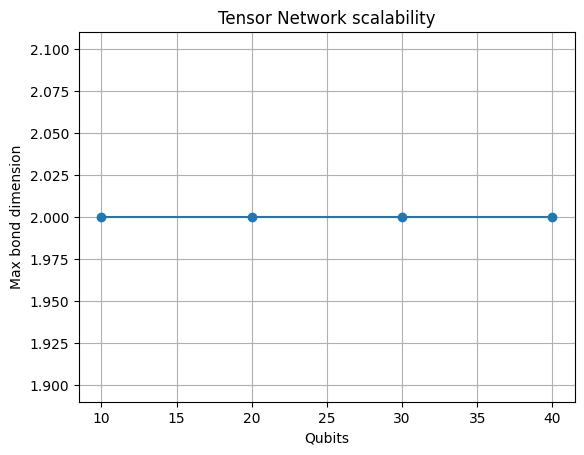

In [47]:
plt.plot(
    qubits,
    bond_dims,
    marker="o"
)

plt.xlabel("Qubits")
plt.ylabel("Max bond dimension")

plt.title(
    "Tensor Network scalability"
)

plt.grid(True)

plt.show()

In [48]:
mps = psi.to_mps()

AttributeError: 'TensorNetworkGenVector' object has no attribute 'to_mps'

In [49]:
circ.psi

TensorNetworkGenVector(tensors=198, indices=237)

In [50]:
mps = psi.to_mps()

AttributeError: 'TensorNetworkGenVector' object has no attribute 'to_mps'

In [51]:
import quimb.tensor as qtn

n_qubits = 20

psi0 = qtn.MPS_computational_state(
    "0" * n_qubits
)

In [52]:
for i in range(n_qubits):

    psi0.gate_(
        qtn.H,
        i
    )

AttributeError: module 'quimb.tensor' has no attribute 'H'

In [53]:
qubits = []
bond_dims = []

for n_qubits in [10,20,30,40]:

    circ = qtn.Circuit(n_qubits)

    for i in range(n_qubits):
        circ.h(i)

    for i in range(n_qubits - 1):
        circ.cz(i, i + 1)

    for i in range(n_qubits):
        circ.rx(0.5, i)

    psi = circ.psi

    qubits.append(n_qubits)

    bond_dims.append(
        psi.max_bond()
    )

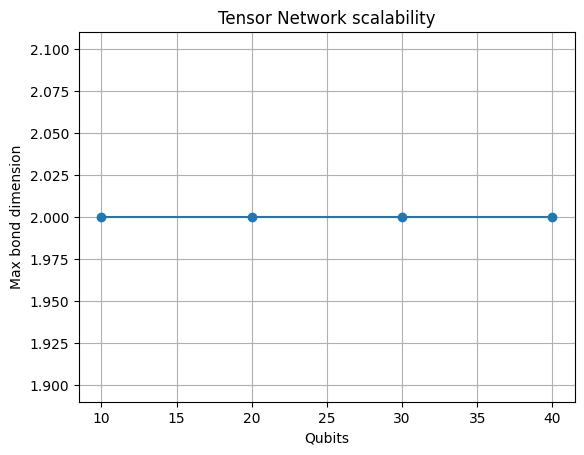

In [54]:
plt.plot(
    qubits,
    bond_dims,
    marker="o"
)

plt.xlabel("Qubits")
plt.ylabel("Max bond dimension")

plt.title(
    "Tensor Network scalability"
)

plt.grid(True)

plt.show()

In [55]:
from app.tensor_networks.qaoa_mps import (
    create_initial_mps
)

psi = create_initial_mps(20)

psi

MatrixProductState(tensors=40, indices=59, L=20, max_bond=2)

In [56]:
import networkx as nx

G_test = nx.path_graph(20)

for i, j in G_test.edges():

    G_test[i][j]["weight"] = 1.0

In [57]:
from app.tensor_networks.qaoa_mps import (
    run_qaoa_mps
)

psi = run_qaoa_mps(
    G_test,
    depth=2,
    gamma=0.5,
    beta=0.3
)

AttributeError: 'tuple' object has no attribute 'inds'

In [ ]:
psi.max_bond()

In [ ]:
psi.entropy(10)